# Info sobre Variables

In [ ]:
def get_var(path_to_csv: str, var: str) -> Variable:
    df = pd.read_csv(path_to_csv, index_col=0)
    row = df[(df.variable == var)].values[0]
    return Variable(variable=row[1], legend=row[2], description=row[3])


# get_var(path_to_csv="variables.csv", var="to")


def add_var(path_to_csv: str, var: Variable) -> None:
    with open(path_to_csv, "a+") as file:
        print(",".join([var.variable, var.legend, var.description]), file=file)


# add_var(path_to_csv="variables_2.csv", var=Variable(variable="000", legend="000", description="000"))

In [ ]:
class Variable(BaseModel):
    variable: str
    legend: str
    description: str


def clean(var: str) -> str:
    var = " ".join(var.split("_"))
    return var.capitalize()


vars = [
    "best_loss_ag",
    "best_acc_ag",
    "best_recall_ag",
    "best_precision_ag",
    "best_f1_ag",
]
for i, v in enumerate(vars):
    add_var(
        path_to_csv="variables.csv",
        var=Variable(variable=v, legend=clean(v), description=clean(v)),
    )

In [ ]:
from pathlib import Path
import pandas as pd
from pydantic import BaseModel


class Variable(BaseModel):
    variable: str
    legend: str
    description: str


def clean(var: str) -> str:
    var = " ".join(var.split("_"))
    return var.capitalize()


FOLDER = Path(
    "/home/slozgom/personal/tfg_project/xperiments/experimentos_con_cnn/05_non_complete/raw"
)
PATHS = list(FOLDER.iterdir())
variables = []
for path in PATHS:
    if path.suffix == ".csv":
        df = pd.read_csv(path)
        variables.extend(list(df.columns))
variables = set(variables)
with open("variables_2.csv", "w") as outfile:
    print("variable,legend,description", file=outfile)
    for var in variables:
        print(",".join([var, clean(var), clean(var)]), file=outfile)

# Plots

### Tabla descriptiva

Ideas: Añadir cantidad de mensajes, tiempo, convergence value, En cuántas rondas llegamos a ese máximo, etc.

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path

FOLDER = Path("/home/slozgom/tgf/tfg_samuel/xperiments/experimentos_con_cnn")

experiment_variables = ["agent", "algorithm", "n_agents", "type", "network"]
agent_variables = [
    "minimum_loss_achieved",
    "maximum_accuracy_achieved",
    "maximum_recall_achieved",
    "maximum_precision_achieved",
    "maximum_f1_achieved",
    "mean_seconds_by_round",
]
network_variables = [
    "minimum_loss_net",
    "maximum_acc_net",
    "maximum_recall_net",
    "maximum_precision_net",
    "maximum_f1_net",
]
df = pd.DataFrame(columns=experiment_variables + agent_variables)


def max_network(data):
    df_numeric = pd.DataFrame(columns=network_variables)
    rounds = data.algorithm_round.unique()
    for r in rounds:
        round_data = data[(data.algorithm_round == r)]
        df_numeric.loc[len(df_numeric),] = list(
            map(
                lambda x: sum(x) / len(x),
                [
                    data.test_loss,
                    data.test_accuracy,
                    data.test_recall,
                    data.test_precision,
                    data.test_f1_score,
                ],
            )
        )
    return [min(df_numeric.best_loss_net)].extend(
        list(
            map(
                max,
                [
                    data.test_accuracy,
                    data.test_recall,
                    data.test_precision,
                    data.test_f1_score,
                ],
            )
        )
    )


# Modificar esta lista
experiments_list = [x for x in list(FOLDER.iterdir()) if "10" in x.name]
for PATH in experiments_list:
    dataset = pd.read_csv(PATH.joinpath("raw/nn_inference.csv"))
    agents = dataset.agent.unique()
    dataset = dataset[(dataset.algorithm_round <= 100)]
    descriptive = PATH.name.split("_")
    times = pd.read_csv(PATH.joinpath("raw/algorithm.csv"))
    times = times[(times.algorithm_round <= 100)]
    for ag in agents:
        agent_times = times[(times.agent == ag + "@localhost")]
        time = agent_times.seconds_to_complete.mean()

        data = dataset[(dataset.agent == ag)]
        numeric = list(
            map(
                max,
                [
                    data.test_accuracy,
                    data.test_recall,
                    data.test_precision,
                    data.test_f1_score,
                ],
            )
        )
        numerics = [data.test_loss.min()] + numeric + [time]
        row = [ag] + ["acol"] + descriptive + numerics
        df.loc[len(df)] = row
df.head(12)

#### ANOVA
- Para la tabla podrían cogerse varios experimentos de cada tipo, en lugar de agentes. De este modo obtendríamos valores más altos
- Posibilidad de combinar varaibles dependientes
- Hacer una Manova
- Divergencia de Kullback Leibler para distribución de probabilidad de las etiquetas de test. La teórica es Uniforme [1000, 1000, 1000, 1000], la predicha podría ser [900, 1200, 800, 1100]
- Colores pastel
- Ser más descriptivo en labels ejes (Unificar etiquetas, diccionario o lo que sea)
- Parametrizar leyendas
- Unificar estadísticos, que se pueda elegir las variables en los ejes.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg
from statsmodels.graphics.factorplots import interaction_plot

data = df[["type", "network", "minimum_loss_achieved"]]
data.groupby(["type", "network"])["minimum_loss_achieved"].agg(["mean", "std"])

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].set_title("Loss vs Type")
sns.boxplot(
    x="type",
    y="minimum_loss_achieved",
    data=data,
    ax=axs[0],
    hue="type",
    palette="pastel",
)
sns.swarmplot(
    x="type", y="minimum_loss_achieved", data=data, color="black", alpha=0.5, ax=axs[0]
)

axs[1].set_title("Loss vs Network")
sns.boxplot(
    x="network",
    y="minimum_loss_achieved",
    data=data,
    ax=axs[1],
    hue="network",
    palette="pastel",
)
sns.swarmplot(
    x="network",
    y="minimum_loss_achieved",
    data=data,
    color="black",
    alpha=0.5,
    ax=axs[1],
)

fig, axs = plt.subplots(1, 1, figsize=(10, 4))
axs.set_title("Loss vs Type and Network")
sns.boxplot(
    x="type",
    y="minimum_loss_achieved",
    hue="network",
    data=data,
    ax=axs,
    palette="pastel",
)

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
fig = interaction_plot(
    x=data.type,
    trace=data.network,
    response=data.minimum_loss_achieved,
    ax=ax,
)

fig, ax = plt.subplots(figsize=(6, 4))
fig = interaction_plot(
    x=data.network,
    trace=data.type,
    response=data.minimum_loss_achieved,
    ax=ax,
)

In [ ]:
# Test ANOVA de dos vías (Two-way ANOVA)
# ==============================================================================
pg.anova(
    data=data, dv="minimum_loss_achieved", between=["type", "network"], detailed=True
).round(4)

#### Test H de Kruskal wallis (No Paramétrico)

In [ ]:
from scipy import stats

g1 = data.minimum_loss_achieved[(data.network == "complete")]
g2 = data.minimum_loss_achieved[(data.network == "ring")]
g3 = data.minimum_loss_achieved[(data.network == "sw")]
print(stats.friedmanchisquare(g1, g2, g3))
print(stats.kruskal(g1, g2, g3))

### Test post-hoc

#### Test post-hoc de Tuckey (Paramétrico)

In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import pingouin as pg

tukey_oneway = pairwise_tukeyhsd(endog=data.minimum_loss_achieved, groups=data.network)
pg_test = pg.pairwise_tukey(
    data=data, dv="minimum_loss_achieved", between="network"
).round(3)

# Display the results
# tukey_oneway.summary()
pg_test

#### Test de Nemenyi (No paramétrico)

In [ ]:
import scikit_posthocs as sp

g1 = data.minimum_loss_achieved[(data.network == "complete")]
g2 = data.minimum_loss_achieved[(data.network == "ring")]
g3 = data.minimum_loss_achieved[(data.network == "sw")]
data_nem = np.array([g1, g2, g3])
a = sp.posthoc_nemenyi_friedman(data_nem.T)
# print(sp.posthoc_nemenyi_friedman(a=data, y_col="minimum_loss_achieved", group_col="network"))

#### MANOVA

In [ ]:
a = result.results["network"]["stat"]
a.reset_index(inplace=True)
a = a.rename(columns={"index": "tests"})
a

In [ ]:
from statsmodels.multivariate.manova import MANOVA

manova = MANOVA.from_formula(
    "minimum_loss_achieved + maximum_accuracy_achieved + maximum_recall_achieved + maximum_precision_achieved + maximum_f1_achieved ~ network",
    data=df,
)
result = manova.mv_test()
print(result)

In [ ]:
df2 = df.copy()
df2.type = df2.type.replace({"iid": "red", "non": "blue"})
df2
df2.plot.scatter(
    x="best_loss_ag",
    y="best_acc_ag",
    c="type",
)

### Gráfico de bolos (Test)

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt

plt.ion()
FOLDER = Path("/home/slozgom/personal/tfg_project/xperiments/experimentos_con_cnn")
experiments_list = list(FOLDER.iterdir())
for i, path in enumerate(experiments_list):
    # print(f"{i} --> {path.name}")
    pass
PATH = experiments_list[14]

data = pd.read_csv(PATH / "raw/algorithm.csv")
agents = ["a0", "a1", "a2", "a3", "a4"]
colors = ["red", "blue", "orange", "green", "pink"]
times = []
for agent in agents:
    agent_data = data[(data.agent == agent + "@localhost")]
    time = list(agent_data.seconds_to_complete)
    times.append(time)

df_bolos = pd.DataFrame(columns=agents)
for t, a in zip(times, agents):
    df_bolos[a] = t

sns.set_style("whitegrid")
sns.violinplot(data=df_bolos, native_scale=True, palette="pastel").set(
    title="Seconds to complete training round by agent"
)
sns.despine(left=True)
plt.xlabel("Agents")
plt.ylabel("Seconds by round")

In [ ]:
import plotly.graph_objects as go
import pandas as pd
from pathlib import Path

FOLDER = Path("/home/slozgom/tfg/tfg_samuel/xperiments/experimentos_con_cnn")
experiments_list = list(FOLDER.iterdir())
PATH = experiments_list[8]

data = pd.read_csv(PATH / "raw/algorithm.csv")
agents = list(map(lambda x: x.split("@")[0], sorted(data.agent.unique())))
times = []
for agent in agents:
    agent_data = data[(data.agent == agent + "@localhost")]
    time = list(agent_data.seconds_to_complete)
    times.append(time)

df_bolos = pd.DataFrame(columns=agents)
for t, a in zip(times, agents):
    df_bolos[a] = t
df_bolos = df_bolos.melt()
fig = go.Figure()
for agent in agents:
    fig.add_trace(
        go.Violin(
            x=df_bolos["variable"][df_bolos["variable"] == agent],
            y=df_bolos["value"][df_bolos["variable"] == agent],
            name=agent,
            box_visible=True,
            meanline_visible=True,
        )
    )
fig.update_layout(title_text="Seconds to complete training round by agent")

fig.show()

### Tabla de frecuencias cruzadas de Mensajes

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns

FOLDER = Path(
    "/home/slozgom/personal/tfg_project/xperiments/experimentos_con_cnn/05_non_complete"
)

dataset = pd.read_csv(FOLDER.joinpath("raw/message.csv"))
dataset = dataset[["sender", "to"]][(dataset.algorithm_round <= 100)]
pd.crosstab(index=dataset.sender, columns=dataset.to)

In [ ]:
import numpy as np
import plotly.graph_objects as go

import plotly.express as px
import pandas as pd
from itertools import groupby

df = pd.read_csv(
    "/home/slozgom/tfg/tfg_samuel/xperiments/experimentos_con_cnn/05_non_complete/raw/nn_convergence.csv"
)
lst = df.layer.unique()
f = lambda x: x.split(".")[0]
layers_opts = {f(k): list(g) for k, g in groupby(sorted(lst, key=f), key=f)}
df = df[
    (df.description == "PRE-TRAIN")
    & df.layer.isin(layers_opts["conv1"])
    & (df.epoch_or_iteration == 1)
]
pivot = df.pivot(columns="layer", values="weight")
df = df[df.layer == layers_opts["conv1"][0]].reset_index()
df[layers_opts["conv1"][0]] = (
    pivot[layers_opts["conv1"][0]].dropna().reset_index()[f"{layers_opts['conv1'][0]}"]
)
df[layers_opts["conv1"][1]] = (
    pivot[layers_opts["conv1"][1]].dropna().reset_index()[f"{layers_opts['conv1'][1]}"]
)
min_x = df[layers_opts["conv1"][0]].min()
min_y = df[layers_opts["conv1"][1]].min()
max_x = df[layers_opts["conv1"][0]].max()
max_y = df[layers_opts["conv1"][1]].max()
line_plot = px.line(
    df,
    x="algorithm_round",
    y=layers_opts["conv1"][0],
    color="agent",
    animation_frame="algorithm_round",
    hover_name="agent",
    range_x=[0, 110],
    range_y=[min_x, max_x],
)
line_plot.update_traces(showlegend=False)  # legend will be from line graph
for frame in line_plot.frames:
    for data in frame.data:
        data.update(mode="lines", opacity=0.8, showlegend=False)

df = df.sort_values(
    [
        "algorithm_round",
        "agent",
    ],
    ignore_index=True,
)
N_UNIQUE_AGENTS = df["agent"].nunique()
df_indexed = pd.DataFrame()
for index in np.arange(start=0, stop=len(df) + 1, step=N_UNIQUE_AGENTS):
    df_slicing = df.iloc[:index].copy()
    df_slicing["frame"] = index // N_UNIQUE_AGENTS
    df_indexed = pd.concat([df_indexed, df_slicing])

# Scatter Plot
scatter_plot = px.scatter(
    df_indexed,
    x="algorithm_round",
    y=layers_opts["conv1"][0],
    animation_frame="frame",
    color="agent",
    hover_name="agent",
    range_x=[0, 110],
    range_y=[min_x, max_x],
)

for frame in scatter_plot.frames:
    for data in frame.data:
        data.update(mode="markers", showlegend=True, opacity=1)
        data["x"] = np.take(data["x"], [-1])
        data["y"] = np.take(data["y"], [-1])

# Line Plot
line_plot = px.line(
    df_indexed,
    x="algorithm_round",
    y=layers_opts["conv1"][0],
    color="agent",
    animation_frame="frame",
    range_x=[0, 110],
    range_y=[min_x, max_x],
    line_shape="spline",  # make a line graph curvy
)
line_plot.update_traces(showlegend=False)  # legend will be from line graph
for frame in line_plot.frames:
    for data in frame.data:
        data.update(mode="lines", opacity=0.8, showlegend=False)

line_plot.update_traces(showlegend=False)  # legend will be from line graph
for frame in line_plot.frames:
    for data in frame.data:
        data.update(mode="lines", opacity=0.8, showlegend=False)

# Stationary combined plot
combined_plot = go.Figure(
    data=line_plot.data + scatter_plot.data,
    frames=[
        go.Frame(data=line_plot.data + scatter_plot.data, name=scatter_plot.name)
        for line_plot, scatter_plot in zip(line_plot.frames, scatter_plot.frames)
    ],
    layout=line_plot.layout,
)

combined_plot.update_yaxes(
    gridcolor="#7a98cf", griddash="dot", gridwidth=0.5, linewidth=2, tickwidth=2
)

combined_plot.update_xaxes(title_font=dict(size=16), linewidth=2, tickwidth=2)

combined_plot.update_traces(line=dict(width=5), marker=dict(size=25))

# adjust speed of animation
combined_plot.layout.updatemenus[0].buttons[0]["args"][1]["frame"]["duration"] = 120
combined_plot.layout.updatemenus[0].buttons[0]["args"][1]["transition"]["duration"] = 50
combined_plot.layout.updatemenus[0].buttons[0]["args"][1]["transition"][
    "redraw"
] = False
combined_plot

In [ ]:
df_indexed.head(30)

In [ ]:
import numpy as np
import pandas as pd

from io import BytesIO
import plotly.express as px
import plotly.graph_objects as go


df = pd.read_csv(
    "https://raw.githubusercontent.com/tomasduricek/animated-graphs/main/retail_data.csv"
)
df["date"] = pd.to_datetime(
    df["date"].astype(str).str[:7], format="%Y-%m"
)  # Control ChatGPT date format output
df = df.sort_values(["date", "retail_group"], ignore_index=True)

RETAIL_GROUP_COLORS = ["#1F4068", "#527A82", "#DE8918", "#BF3200"]
FIRST_DAY_OF_ALL_YEARS = df[df["date"].dt.month == 1]["date"].unique()
N_UNIQUE_RETAIL_GROUPS = df["retail_group"].nunique()

df_indexed = pd.DataFrame()
for index in np.arange(start=0, stop=len(df) + 1, step=N_UNIQUE_RETAIL_GROUPS):
    df_slicing = df.iloc[:index].copy()
    df_slicing["frame"] = index // N_UNIQUE_RETAIL_GROUPS
    df_indexed = pd.concat([df_indexed, df_slicing])

# Scatter Plot
scatter_plot = px.scatter(
    df_indexed,
    x="date",
    y="average_monthly_income",
    color="retail_group",
    animation_frame="frame",
    color_discrete_sequence=RETAIL_GROUP_COLORS,
)

for frame in scatter_plot.frames:
    for data in frame.data:
        data.update(mode="markers", showlegend=True, opacity=1)
        data["x"] = np.take(data["x"], [-1])
        data["y"] = np.take(data["y"], [-1])

# Line Plot
line_plot = px.line(
    df_indexed,
    x="date",
    y="average_monthly_income",
    color="retail_group",
    animation_frame="frame",
    color_discrete_sequence=RETAIL_GROUP_COLORS,
    width=1000,
    height=500,
    line_shape="spline",  # make a line graph curvy
)
line_plot.update_traces(showlegend=False)  # legend will be from line graph
for frame in line_plot.frames:
    for data in frame.data:
        data.update(mode="lines", opacity=0.8, showlegend=False)

# Stationary combined plot
combined_plot = go.Figure(
    data=line_plot.data + scatter_plot.data,
    frames=[
        go.Frame(data=line_plot.data + scatter_plot.data, name=scatter_plot.name)
        for line_plot, scatter_plot in zip(line_plot.frames, scatter_plot.frames)
    ],
    layout=line_plot.layout,
)

combined_plot.update_yaxes(
    gridcolor="#7a98cf", griddash="dot", gridwidth=0.5, linewidth=2, tickwidth=2
)

combined_plot.update_xaxes(title_font=dict(size=16), linewidth=2, tickwidth=2)

combined_plot.update_traces(line=dict(width=5), marker=dict(size=25))

combined_plot.update_layout(
    font=dict(size=18),
    yaxis=dict(tickfont=dict(size=16)),
    xaxis=dict(tickfont=dict(size=16)),
    showlegend=True,
    legend=dict(title="Retail group"),
    template="simple_white",
    title="<b>Monthly Retail Prices During Covid-19</b>",
    yaxis_title="<b>Average price (k)</b>",
    xaxis_title="<b>Date</b>",
    yaxis_showgrid=True,
    xaxis_range=[
        df_indexed["date"].min() + pd.DateOffset(months=3),
        df_indexed["date"].max() + pd.DateOffset(months=3),
    ],
    yaxis_range=[
        df_indexed["average_monthly_income"].min() * 0.75,
        df_indexed["average_monthly_income"].max() * 1.25,
    ],
    plot_bgcolor="#fffcf7",
    paper_bgcolor="#fffcf7",
    title_x=0.5,
)

# adjust speed of animation
combined_plot["layout"].pop("sliders")
combined_plot.layout.updatemenus[0].buttons[0]["args"][1]["frame"]["duration"] = 120
combined_plot.layout.updatemenus[0].buttons[0]["args"][1]["transition"]["duration"] = 50
combined_plot.layout.updatemenus[0].buttons[0]["args"][1]["transition"][
    "redraw"
] = False


# Autoscaled Combined Plot
combined_plot = go.Figure(
    data=line_plot.data + scatter_plot.data,
    frames=[
        frame.update(
            layout={
                "xaxis": {
                    "range": [
                        min(frame.data[0].x),
                        max(frame.data[0].x + pd.DateOffset(months=2)),
                    ],
                    "tickformat": "%Y",
                    "tickangle": 0,
                    "tickvals": FIRST_DAY_OF_ALL_YEARS,
                },
                "yaxis": {
                    "range": [min(frame.data[0].y) * 0.3, max(frame.data[0].y) * 1.5],
                    "nticks": 6,
                },
            }
        )
        for frame in combined_plot.frames
    ],
    layout=line_plot.layout,
)

combined_plot.update_yaxes(
    gridcolor="#7a98cf", griddash="dot", gridwidth=0.5, linewidth=2, tickwidth=2
)

combined_plot.update_xaxes(title_font=dict(size=16), linewidth=2, tickwidth=2)

combined_plot.update_traces(line=dict(width=5), marker=dict(size=25))

combined_plot.update_layout(
    font=dict(size=18),
    yaxis=dict(tickfont=dict(size=16)),
    xaxis=dict(tickfont=dict(size=16)),
    showlegend=True,
    legend=dict(title="Retail group"),
    template="simple_white",
    title="<b>Monthly Retail Prices During Covid-19</b>",
    yaxis_title="<b>Average price (k)</b>",
    xaxis_title="<b>Date",
    yaxis_showgrid=True,
    xaxis_range=[
        df_indexed["date"].min() + pd.DateOffset(months=3),
        df_indexed["date"].max() + pd.DateOffset(months=3),
    ],
    yaxis_range=[
        df_indexed["average_monthly_income"].min() * 0.75,
        df_indexed["average_monthly_income"].max() * 1.25,
    ],
    plot_bgcolor="#fffcf7",
    paper_bgcolor="#fffcf7",
    title_x=0.5,
)

# adjust speed of animation
combined_plot["layout"].pop("sliders")
combined_plot.layout.updatemenus[0].buttons[0]["args"][1]["frame"]["duration"] = 150
combined_plot.layout.updatemenus[0].buttons[0]["args"][1]["transition"][
    "duration"
] = 120
combined_plot.layout.updatemenus[0].buttons[0]["args"][1]["transition"][
    "redraw"
] = False
combined_plot.show()

In [ ]:
edges = pd.read_csv(
    "/home/slozgom/tfg/tfg_samuel/xperiments/experimentos_con_cnn/05_non_complete/raw/message.csv"
)
edges = edges[["sender", "to", "timestamp", "algorithm_round"]][
    edges.type == "SEND-LAYERS"
]
edges[["sender", "domain"]] = edges.sender.str.split("@", expand=True)
edges[["to", "domain2"]] = edges.to.str.split("@", expand=True)
edges = edges.drop(["domain", "domain2", "algorithm_round"], axis=1)
edges["weight"] = edges.groupby(["sender", "to"]).cumcount().add(1)
edges = edges.assign(line_color="yellow")
edges.timestamp = pd.to_datetime(edges.timestamp)
edges.timestamp = edges.timestamp.dt.strftime("%Y/%m/%d %H:%M:%S")


def set_value(row_number, assigned_value):
    return assigned_value[row_number]


event_dictionary = {}
edges["sender_coords"] = edges.sender.apply(set_value, args=(event_dictionary,))
edges["to_coords"] = edges.to.apply(set_value, args=(event_dictionary,))
edges["edges_X"] = edges.apply(
    lambda row: [row.sender_coords[0], row.to_coords[0]], axis=1
)
edges["edges_Y"] = edges.apply(
    lambda row: [row.sender_coords[1], row.to_coords[1]], axis=1
)
edges.head(10)

This df in case we want combined plot with points and lines

In [ ]:
merge = pd.merge(nodes, edges, how="outer")
scatter_plot = px.scatter(
    nodes,
    x="X",
    y="Y",
    size="size",
    animation_frame="timestamp",
    text="agent",
    color="test_accuracy",
    hover_name="agent",
    range_color=range_color,
)
scatter_plot.update_traces(textposition="top center")
scatter_plot.layout.updatemenus[0].buttons[0].args[1]["frame"]["duration"] = 50
scatter_plot

Here to test with edges plot

In [ ]:
import plotly.graph_objects as go

fig = go.Figure(
    data=[go.Scatter(x=[0, 1, 4], y=[0, 1, -3])],
    layout=go.Layout(
        xaxis=dict(range=[0, 5], autorange=False),
        yaxis=dict(range=[0, 5], autorange=False),
        title=dict(text="Start Title"),
        updatemenus=[
            dict(
                type="buttons",
                buttons=[dict(label="Play", method="animate", args=[None])],
            )
        ],
    ),
    frames=[
        go.Frame(data=[go.Scatter(x=[1, 2], y=[1, 2]), go.Scatter(x=[1, 0], y=[1, 5])]),
        go.Frame(data=[go.Scatter(x=[5, 4], y=[5, 4])]),
        go.Frame(
            data=[go.Scatter(x=[3, 4], y=[3, 4])],
            layout=go.Layout(title_text="End Title"),
        ),
    ],
)

fig.show()

In [ ]:
def get_line_frames(row):
    return {
        "type": "scatter",
        "name": row.sender,
        "x": row.edges_X,
        "y": row.edges_Y,
        "hoverinfo": "name+text",
        "marker": {
            "opacity": 1.0,
            "symbol": "circle",
            "line": {"width": row.weight, "color": "rgba(50,50,50,0.8)"},
        },
        "line": {"color": "rgba(255,79,38,1.000000)"},
        "mode": "lines",
        "fillcolor": "rgba(255,79,38,0.600000)",
        "legendgroup": "f1",
        "showlegend": True,
    }


frames = []
times = edges.timestamp.unique()
for timestamp in times:
    frame_data = edges[edges.timestamp == timestamp]
    frame = {
        "name": timestamp,
        "layout": {},
        "data": frame_data.apply(get_line_frames, axis=1).to_list(),
    }
    frames.append(frame)

len(frames)

In [ ]:
import plotly.graph_objects as go


def get_silders_line(time):
    return {
        "args": [
            [time],
            {
                "frame": {"duration": 500.0, "easing": "linear", "redraw": False},
                "transition": {"duration": 0, "easing": "linear"},
            },
        ],
        "label": time,
        "method": "animate",
    }


fig = go.Figure(
    [
        {
            "type": "scatter",
            "name": "a0",
            "x": [1, 1],
            "y": [3, 2],
            "hoverinfo": "name+text",
            "marker": {
                "opacity": 1.0,
                "symbol": "circle",
                "line": {"width": 0, "color": "rgba(50,50,50,0.8)"},
            },
            "line": {"color": "rgba(255,79,38,1.000000)"},
            "mode": "lines",
            "fillcolor": "rgba(255,79,38,0.600000)",
            "legendgroup": "f1",
            "showlegend": True,
            "xaxis": "x1",
            "yaxis": "y1",
        },
        {
            "type": "scatter",
            "name": "a1",
            "x": [1, 2],
            "y": [3, 4],
            "hoverinfo": "name+text",
            "marker": {
                "opacity": 1.0,
                "symbol": "circle",
                "line": {"width": 0, "color": "rgba(50,50,50,0.8)"},
            },
            "line": {"color": "rgba(79,102,165,1.000000)"},
            "mode": "lines",
            "fillcolor": "rgba(79,102,165,0.600000)",
            "legendgroup": "f2",
            "showlegend": True,
            "xaxis": "x2",
            "yaxis": "y2",
        },
        {
            "type": "scatter",
            "name": "a2",
            "x": [2, 3],
            "y": [3, 2],
            "hoverinfo": "name+text",
            "marker": {
                "opacity": 1.0,
                "symbol": "circle",
                "line": {"width": 0, "color": "rgba(50,50,50,0.8)"},
            },
            "line": {"color": "rgba(255,79,38,1.000000)"},
            "mode": "lines",
            "fillcolor": "rgba(255,79,38,0.600000)",
            "legendgroup": "f1",
            "showlegend": True,
            "xaxis": "x1",
            "yaxis": "y1",
        },
        {
            "type": "scatter",
            "name": "a3",
            "x": [3, 4],
            "y": [3, 5],
            "hoverinfo": "name+text",
            "marker": {
                "opacity": 1.0,
                "symbol": "circle",
                "line": {"width": 0, "color": "rgba(50,50,50,0.8)"},
            },
            "line": {"color": "rgba(79,102,165,1.000000)"},
            "mode": "lines",
            "fillcolor": "rgba(79,102,165,0.600000)",
            "legendgroup": "f2",
            "showlegend": True,
            "xaxis": "x2",
            "yaxis": "y2",
        },
        {
            "type": "scatter",
            "name": "a4",
            "x": [4, 5],
            "y": [3, 0],
            "hoverinfo": "name+text",
            "marker": {
                "opacity": 1.0,
                "symbol": "circle",
                "line": {"width": 0, "color": "rgba(50,50,50,0.8)"},
            },
            "line": {"color": "rgba(79,102,165,1.000000)"},
            "mode": "lines",
            "fillcolor": "rgba(79,102,165,0.600000)",
            "legendgroup": "f2",
            "showlegend": True,
            "xaxis": "x2",
            "yaxis": "y2",
        },
    ],
    layout=dict(
        xaxis1={"domain": [0.0, 0.44], "anchor": "y1", "title": "x", "range": [0, 5]},
        yaxis1={"domain": [0.0, 1.0], "anchor": "x1", "title": "y", "range": [0, 5]},
        xaxis2={"domain": [0.0, 0.44], "anchor": "y1", "title": "x", "range": [0, 5]},
        yaxis2={"domain": [0.0, 1.0], "anchor": "x1", "title": "y", "range": [0, 5]},
        xaxis3={"domain": [0.0, 0.44], "anchor": "y1", "title": "x", "range": [0, 5]},
        yaxis3={"domain": [0.0, 1.0], "anchor": "x1", "title": "y", "range": [0, 5]},
        xaxis4={"domain": [0.0, 0.44], "anchor": "y1", "title": "x", "range": [0, 5]},
        yaxis4={"domain": [0.0, 1.0], "anchor": "x1", "title": "y", "range": [0, 5]},
        xaxis5={"domain": [0.0, 0.44], "anchor": "y1", "title": "x", "range": [0, 5]},
        yaxis5={"domain": [0.0, 1.0], "anchor": "x1", "title": "y", "range": [0, 5]},
        title="",
        margin={"t": 50, "b": 50, "l": 50, "r": 50},
        updatemenus=[
            {
                "buttons": [
                    {
                        "args": [
                            times,
                            {
                                "frame": {"duration": 500.0, "redraw": False},
                                "fromcurrent": True,
                                "transition": {"duration": 0, "easing": "linear"},
                            },
                        ],
                        "label": "Play",
                        "method": "animate",
                    },
                    {
                        "args": [
                            [None],
                            {
                                "frame": {"duration": 0, "redraw": False},
                                "mode": "immediate",
                                "transition": {"duration": 0},
                            },
                        ],
                        "label": "Pause",
                        "method": "animate",
                    },
                ],
                "direction": "left",
                "pad": {"r": 10, "t": 85},
                "showactive": True,
                "type": "buttons",
                "x": 0.1,
                "y": 0,
                "xanchor": "right",
                "yanchor": "top",
            }
        ],
        sliders=[
            {
                "yanchor": "top",
                "xanchor": "left",
                "currentvalue": {
                    "font": {"size": 16},
                    "prefix": "Frame: ",
                    "visible": True,
                    "xanchor": "right",
                },
                "transition": {"duration": 500.0, "easing": "linear"},
                "pad": {"b": 10, "t": 50},
                "len": 0.9,
                "x": 0.1,
                "y": 0,
                "steps": list(map(get_silders_line, times)),
            }
        ],
    ),
    frames=frames,
)
fig

### Network evolution

In [ ]:
import plotly.graph_objects as go
import pandas as pd
from pathlib import Path
import networkx as nx

FOLDER = Path("/home/slozgom/tfg/tfg_samuel/xperiments/experimentos_con_cnn")
experiments_list = list(FOLDER.iterdir())
PATH = experiments_list[8]

data = pd.read_csv(PATH / "raw/message.csv")
data.sender = data.sender.apply(lambda x: x.split("@")[0])
data.to = data.to.apply(lambda x: x.split("@")[0])
agents = sorted(data.sender.unique())
data = data[["sender", "to"]][(data.algorithm_round <= 100)]
cross = pd.crosstab(index=data.sender, columns=data.to)
G = nx.random_geometric_graph(len(agents), 0)
G = nx.relabel_nodes(G, {i: a for i, a in enumerate(agents)})
tuples = cross.stack().reset_index()
tuples = tuples[tuples[0] > 0]
tuples = list(tuples.itertuples(index=False))
G.add_weighted_edges_from(tuples)
nx.draw_networkx(G)

In [ ]:
G = nx.random_geometric_graph(len(agents), 0)
G = nx.relabel_nodes(G, {i: a for i, a in enumerate(agents)})
tuples = cross.stack().reset_index()
tuples = tuples[tuples[0] > 0]
tuples = list(tuples.itertuples(index=False))
G.add_weighted_edges_from(tuples)
nx.draw_networkx(G)

In [ ]:
import numpy as np
import plotly.graph_objects as go

import plotly.express as px
import pandas as pd
from itertools import groupby

import plotly.graph_objects as go
import pandas as pd
from pathlib import Path
import networkx as nx

FOLDER = Path("/home/slozgom/tfg/tfg_samuel/xperiments/experimentos_con_cnn")
experiments_list = list(FOLDER.iterdir())
PATH = experiments_list[8]

data = pd.read_csv(PATH / "raw/message.csv")
data.sender = data.sender.apply(lambda x: x.split("@")[0])
data.to = data.to.apply(lambda x: x.split("@")[0])
agents = sorted(data.sender.unique())
data = data[["sender", "to"]][(data.algorithm_round <= 100)]
cross = pd.crosstab(index=data.sender, columns=data.to)
G = nx.random_geometric_graph(len(agents), 0)
G = nx.relabel_nodes(G, {i: a for i, a in enumerate(agents)})
tuples = cross.stack().reset_index()
tuples = tuples[tuples[0] > 0]
tuples = list(tuples.itertuples(index=False))
G.add_weighted_edges_from(tuples)

# Edges
edges = pd.read_csv(
    "/home/slozgom/tfg/tfg_samuel/xperiments/experimentos_con_cnn/05_non_complete/raw/message.csv"
)
edges = edges[["sender", "to", "timestamp", "algorithm_round"]][
    edges.type == "SEND-LAYERS"
]

# Nodes
nodes = pd.read_csv(
    "/home/slozgom/tfg/tfg_samuel/xperiments/experimentos_con_cnn/05_non_complete/raw/nn_inference.csv"
)
nodes = nodes[["agent", "timestamp", "test_accuracy"]]
nodes

nodes.timestamp = pd.to_datetime(nodes.timestamp)
nodes.timestamp = nodes.timestamp.dt.strftime("%Y/%m/%d %H:%M:%S")
nodes["agent_id"] = nodes.groupby(nodes.columns.tolist(), sort=False).ngroup() + 1
mux = pd.MultiIndex.from_product(
    [nodes["timestamp"].unique(), np.array(nodes.agent.unique())],
    names=["timestamp", "agent"],
)

nodes = nodes.set_index(["timestamp", "agent"]).reindex(mux).reset_index()
for agent in nodes.agent.unique():
    nodes[nodes.agent == agent] = nodes[nodes.agent == agent].fillna(method="ffill")
nodes = nodes.fillna(0)


node_x = []
node_y = []
for node in G.nodes():
    x, y = G.nodes[node]["pos"]
    node_x.append(x)
    node_y.append(y)


def set_value(row_number, assigned_value):
    return assigned_value[row_number]


np.random.seed(2)
# coords = np.random.rand(5, 2)
x_dictionary = {x: node_x[i] for i, x in enumerate(nodes.agent.unique())}
y_dictionary = {x: node_y[i] for i, x in enumerate(nodes.agent.unique())}

# Add a new column named 'Price'
nodes["X"] = nodes["agent"].apply(set_value, args=(x_dictionary,))
nodes["Y"] = nodes["agent"].apply(set_value, args=(y_dictionary,))
range_color = [float(nodes.test_accuracy.min()), float(nodes.test_accuracy.max())]
nodes["size"] = [10 for x in range(len(nodes))]
scatter_plot = px.scatter(
    nodes,
    x="X",
    y="Y",
    animation_frame="timestamp",
    text="agent",
    color="test_accuracy",
    size="size",
    hover_name="agent",
    range_color=range_color,
)
scatter_plot.update_traces(textposition="top center")
scatter_plot.layout.updatemenus[0].buttons[0].args[1]["frame"]["duration"] = 50

# EDGE TRACE
edge_x = []
edge_y = []
for edge in G.edges():
    x0, y0 = G.nodes[edge[0]]["pos"]
    x1, y1 = G.nodes[edge[1]]["pos"]
    edge_x.append(x0)
    edge_x.append(x1)
    edge_x.append(None)
    edge_y.append(y0)
    edge_y.append(y1)
    edge_y.append(None)

edge_trace = go.Scatter(
    x=edge_x,
    y=edge_y,
    line=dict(width=0.5, color="#888"),
    hoverinfo="none",
    mode="lines",
    showlegend=False,
)
scatter_plot.update_layout(title_text="Scatter + line network")
scatter_plot.add_trace(edge_trace)

scatter_plot

### Another

In [ ]:
import os
from pathlib import Path
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
from itertools import groupby
import numpy as np

FOLDER = Path("/home/slozgom/tfg/tfg_samuel/xperiments/experimentos_con_cnn")
experiments_list = list(FOLDER.iterdir())
PATH = experiments_list[8]

df = pd.read_csv(
    "/home/slozgom/tfg/tfg_samuel/xperiments/experimentos_con_cnn/05_non_complete/raw/nn_convergence.csv"
)
lst = df.layer.unique()
f = lambda x: x.split(".")[0]
layers_opts = {f(k): list(g) for k, g in groupby(sorted(lst, key=f), key=f)}
df = df[
    (df.description == "PRE-TRAIN")
    & df.layer.isin(layers_opts["conv1"])
    & (df.epoch_or_iteration == 1)
]
pivot = df.pivot(columns="layer", values="weight")
df = df[df.layer == layers_opts["conv1"][0]].reset_index()
df[layers_opts["conv1"][0]] = (
    pivot[layers_opts["conv1"][0]].dropna().reset_index()[f"{layers_opts['conv1'][0]}"]
)
df[layers_opts["conv1"][1]] = (
    pivot[layers_opts["conv1"][1]].dropna().reset_index()[f"{layers_opts['conv1'][1]}"]
)
min_x = df[layers_opts["conv1"][0]].min()
min_y = df[layers_opts["conv1"][1]].min()
max_x = df[layers_opts["conv1"][0]].max()
max_y = df[layers_opts["conv1"][1]].max()
fig = px.scatter(
    df,
    x=layers_opts["conv1"][0],
    y=layers_opts["conv1"][1],
    animation_frame="algorithm_round",
    color="agent",
    hover_name="agent",
    range_x=[min_x, max_x],
    range_y=[min_y, max_y],
)
fig.update_layout(title_text="First plot")

"""
Second Figure
"""

df = pd.read_csv(
    "/home/slozgom/tfg/tfg_samuel/xperiments/experimentos_con_cnn/05_non_complete/raw/nn_convergence.csv"
)
lst = df.layer.unique()
f = lambda x: x.split(".")[0]
layers_opts = {f(k): list(g) for k, g in groupby(sorted(lst, key=f), key=f)}
df = df[
    (df.description == "PRE-TRAIN")
    & df.layer.isin(layers_opts["conv1"])
    & (df.epoch_or_iteration == 1)
]
pivot = df.pivot(columns="layer", values="weight")
df = df[df.layer == layers_opts["conv1"][0]].reset_index()
df[layers_opts["conv1"][0]] = (
    pivot[layers_opts["conv1"][0]].dropna().reset_index()[f"{layers_opts['conv1'][0]}"]
)
df[layers_opts["conv1"][1]] = (
    pivot[layers_opts["conv1"][1]].dropna().reset_index()[f"{layers_opts['conv1'][1]}"]
)
min_x = df[layers_opts["conv1"][0]].min()
min_y = df[layers_opts["conv1"][1]].min()
max_x = df[layers_opts["conv1"][0]].max()
max_y = df[layers_opts["conv1"][1]].max()
line_plot = px.line(
    df,
    x="algorithm_round",
    y=layers_opts["conv1"][0],
    color="agent",
    animation_frame="algorithm_round",
    hover_name="agent",
    range_x=[0, 110],
    range_y=[min_x, max_x],
)
line_plot.update_traces(showlegend=False)  # legend will be from line graph
for frame in line_plot.frames:
    for data in frame.data:
        data.update(mode="lines", opacity=0.8, showlegend=False)

df = df.sort_values(
    [
        "algorithm_round",
        "agent",
    ],
    ignore_index=True,
)
N_UNIQUE_AGENTS = df["agent"].nunique()
df_indexed = pd.DataFrame()
for index in np.arange(start=0, stop=len(df) + 1, step=N_UNIQUE_AGENTS):
    df_slicing = df.iloc[:index].copy()
    df_slicing["frame"] = index // N_UNIQUE_AGENTS
    df_indexed = pd.concat([df_indexed, df_slicing])

# Scatter Plot
scatter_plot = px.scatter(
    df_indexed,
    x="algorithm_round",
    y=layers_opts["conv1"][0],
    animation_frame="frame",
    color="agent",
    hover_name="agent",
    range_x=[0, 110],
    range_y=[min_x, max_x],
)

for frame in scatter_plot.frames:
    for data in frame.data:
        data.update(mode="markers", showlegend=True, opacity=1)
        data["x"] = np.take(data["x"], [-1])
        data["y"] = np.take(data["y"], [-1])

# Line Plot
line_plot = px.line(
    df_indexed,
    x="algorithm_round",
    y=layers_opts["conv1"][0],
    color="agent",
    animation_frame="frame",
    range_x=[0, 110],
    range_y=[min_x, max_x],
    line_shape="spline",  # make a line graph curvy
)
line_plot.update_traces(showlegend=False)  # legend will be from line graph
for frame in line_plot.frames:
    for data in frame.data:
        data.update(mode="lines", opacity=0.8, showlegend=False)

line_plot.update_traces(showlegend=False)  # legend will be from line graph
for frame in line_plot.frames:
    for data in frame.data:
        data.update(mode="lines", opacity=0.8, showlegend=False)

# Stationary combined plot
combined_plot = go.Figure(
    data=line_plot.data + scatter_plot.data,
    frames=[
        go.Frame(data=line_plot.data + scatter_plot.data, name=scatter_plot.name)
        for line_plot, scatter_plot in zip(line_plot.frames, scatter_plot.frames)
    ],
    layout=line_plot.layout,
)

combined_plot.update_yaxes(
    gridcolor="#7a98cf", griddash="dot", gridwidth=0.5, linewidth=2, tickwidth=2
)

combined_plot.update_xaxes(title_font=dict(size=16), linewidth=2, tickwidth=2)

combined_plot.update_traces(line=dict(width=5), marker=dict(size=25))

# adjust speed of animation
combined_plot.layout.updatemenus[0].buttons[0]["args"][1]["frame"]["duration"] = 120
combined_plot.layout.updatemenus[0].buttons[0]["args"][1]["transition"]["duration"] = 50
combined_plot.layout.updatemenus[0].buttons[0]["args"][1]["transition"][
    "redraw"
] = False
combined_plot.update_layout(title_text="Combined plot")

## Line evolution

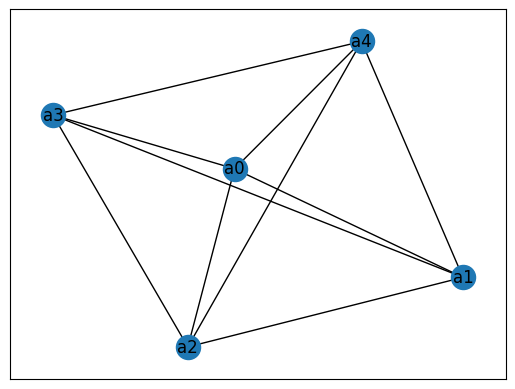

In [115]:
import plotly.graph_objects as go
import pandas as pd
from pathlib import Path
import networkx as nx

FOLDER = Path("/home/slozgom/tfg/tfg_samuel/xperiments/experimentos_con_cnn")
experiments_list = list(FOLDER.iterdir())
PATH = experiments_list[8]

data = pd.read_csv(PATH / "raw/message.csv")
data.sender = data.sender.apply(lambda x: x.split("@")[0])
data.to = data.to.apply(lambda x: x.split("@")[0])
agents = sorted(data.sender.unique())
data = data[["sender", "to"]][(data.algorithm_round <= 100)]
cross = pd.crosstab(index=data.sender, columns=data.to)
G = nx.random_geometric_graph(len(agents), 0)
G = nx.relabel_nodes(G, {i: a for i, a in enumerate(agents)})
tuples = cross.stack().reset_index()
tuples = tuples[tuples[0] > 0]
tuples = list(tuples.itertuples(index=False))
G.add_weighted_edges_from(tuples)
nx.draw_networkx(G)

# NETOWORK LINES

In [154]:
import plotly.graph_objects as go
import pandas as pd
from pathlib import Path
import networkx as nx
import numpy as np
import warnings

warnings.filterwarnings("ignore")

FOLDER = Path("/home/slozgom/tfg/tfg_samuel/xperiments/experimentos_con_cnn")
experiments_list = list(FOLDER.iterdir())
PATH = experiments_list[8]

data = pd.read_csv(PATH / "raw/message.csv")
data.sender = data.sender.apply(lambda x: x.split("@")[0])
data.to = data.to.apply(lambda x: x.split("@")[0])
agents = sorted(data.sender.unique())
data = data[["sender", "to"]][(data.algorithm_round <= 100)]
cross = pd.crosstab(index=data.sender, columns=data.to)
G = nx.random_geometric_graph(len(agents), 0)
G = nx.relabel_nodes(G, {i: a for i, a in enumerate(agents)})
tuples = cross.stack().reset_index()
tuples = tuples[tuples[0] > 0]
tuples = list(tuples.itertuples(index=False))
G.add_weighted_edges_from(tuples)

node_x = []
node_y = []
for node in G.nodes():
    x, y = G.nodes[node]["pos"]
    node_x.append(x)
    node_y.append(y)


def set_value(row_number, assigned_value):
    return assigned_value[row_number]


np.random.seed(2)
# coords = np.random.rand(5, 2)
x_dictionary = {x: node_x[i] for i, x in enumerate(agents)}
y_dictionary = {x: node_y[i] for i, x in enumerate(agents)}

edges = pd.read_csv(
    "/home/slozgom/tfg/tfg_samuel/xperiments/experimentos_con_cnn/05_non_complete/raw/message.csv"
)
edges = edges[["sender", "to", "timestamp", "algorithm_round"]][
    edges.type == "SEND-LAYERS"
]
edges[["sender", "domain"]] = edges.sender.str.split("@", expand=True)
edges[["to", "domain2"]] = edges.to.str.split("@", expand=True)
edges = edges.drop(["domain", "domain2", "algorithm_round"], axis=1)
edges["edge"] = list(map(lambda x: tuple(sorted(x)), zip(edges.sender, edges.to)))
edges["weight"] = edges.groupby(["edge"]).cumcount().add(1)
# edges = edges.assign(line_color="yellow")
edges["timestamp"] = pd.to_datetime(edges.timestamp)
edges["timestamp"] = edges.timestamp.dt.strftime("%Y/%m/%d %H:%M:%S")
edges["timestamp"] = pd.to_datetime(edges.timestamp)
first_date = edges.timestamp.min()
edges["timestamp"] = edges.timestamp.apply(
    lambda x: str(round((x - first_date) / pd.Timedelta(seconds=1), 2))
)

keep = edges.groupby(["timestamp", "edge"])["timestamp"].idxmax()
edges = edges.loc[keep]
mux = pd.MultiIndex.from_product(
    [edges["timestamp"].unique(), np.array(edges.edge.unique())],
    names=["timestamp", "edge"],
)
edges = edges.set_index(["timestamp", "edge"]).reindex(mux).reset_index()
for agent in edges.edge.unique():
    edges[edges.edge == agent] = edges[edges.edge == agent].fillna(method="ffill")
edges = edges.fillna(0)
edges["sender"] = list(map(lambda x: x[0], edges.edge))
edges["to"] = list(map(lambda x: x[1], edges.edge))

edges["X_sender"] = edges["sender"].apply(set_value, args=(x_dictionary,))
edges["Y_sender"] = edges["sender"].apply(set_value, args=(y_dictionary,))
edges["X_to"] = edges["to"].apply(set_value, args=(x_dictionary,))
edges["Y_to"] = edges["to"].apply(set_value, args=(y_dictionary,))
edges["X"] = list(map(lambda x: [x[0], x[1]], list(zip(edges.X_sender, edges.X_to))))
edges["Y"] = list(map(lambda x: [x[0], x[1]], list(zip(edges.Y_sender, edges.Y_to))))
edges = edges.drop(["sender", "to", "X_sender", "Y_sender", "X_to", "Y_to"], axis=1)

In [156]:
import plotly.graph_objects as go
import numpy as np


def new_value(value):
    OldMin = edges.weight.min()
    OldMax = edges.weight.max()
    OldRange = OldMax - OldMin
    NewMin = 0
    NewMax = 20
    NewRange = 20 - 0
    return round((((value - OldMin) * NewRange) / OldRange) + NewMin)


fig = go.Figure()
links = edges.edge.unique()
times = edges.timestamp.unique()
# TRACES
for link in links:
    x = edges[(edges.edge == link)].head(1).X.values[0]
    y = edges[(edges.edge == link)].head(1).Y.values[0]
    fig.add_scatter(x=x, y=y, name=str(link), mode="lines", line_width=1)

# SLIDER
sliders_dict = {
    "active": 0,
    "yanchor": "top",
    "xanchor": "left",
    "currentvalue": {
        "font": {"size": 20},
        "prefix": "Second:",
        "visible": True,
        "xanchor": "right",
    },
    "transition": {"duration": 25, "easing": "cubic-in-out"},
    "pad": {"b": 10, "t": 50},
    "len": 0.9,
    "x": 0.1,
    "y": 0,
    "steps": [],
}

# FRAMES
frames = []
for time in times:
    data = []
    for link in links:
        row = edges[(edges.edge == link) & (edges.timestamp == time)]
        data.append(
            go.Scatter(
                x=row.X.values[0],
                y=row.Y.values[0],
                name=f"{str(link)} - {row.weight.values[0]}",
                mode="lines",
                line_width=new_value(row.weight.values[0]),
            )
        )
    frames.append(go.Frame(data=data, traces=list(range(len(links))), name=str(time)))
    slider_step = {
        "args": [
            [str(time)],
            {
                "mode": "immediate",
                "transition": {"duration": 25},
            },
        ],
        "label": str(time),
        "method": "animate",
    }
    sliders_dict["steps"].append(slider_step)


fig.update(frames=frames)
updatemenus = [
    dict(
        buttons=[
            dict(
                args=[
                    None,
                    {"frame": {"duration": 50, "redraw": True}, "fromcurrent": True},
                ],
                label="Play",
                method="animate",
            ),
            dict(
                args=[
                    [None],
                    {
                        "frame": {"duration": 0, "redraw": False},
                        "mode": "immediate",
                        "transition": {"duration": 0},
                    },
                ],
                label="Pause",
                method="animate",
            ),
        ],
        direction="left",
        pad={"r": 10, "t": 87},
        showactive=False,
        type="buttons",
        x=0.1,
        xanchor="right",
        y=0,
        yanchor="top",
    )
]

fig.update_layout(
    width=800,
    height=800,
    updatemenus=updatemenus,
    sliders=[sliders_dict],
)
fig.update_xaxes(range=[0, 1])
fig.update_yaxes(range=[0, 1])
fig

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'line': {'width': 1},
              'mode': 'lines',
              'name': "('a0', 'a1')",
              'type': 'scatter',
              'x': [0.7553729332692651, 0.8744792556495565],
              'y': [0.46218945453484983, 0.368836932239586]},
             {'line': {'width': 1},
              'mode': 'lines',
              'name': "('a0', 'a2')",
              'type': 'scatter',
              'x': [0.7553729332692651, 0.36654986060105477],
              'y': [0.46218945453484983, 0.6600052140069519]},
             {'line': {'width': 1},
              'mode': 'lines',
              'name': "('a0', 'a3')",
              'type': 'scatter',
              'x': [0.7553729332692651, 0.9502135486898563],
              'y': [0.46218945453484983, 0.16264730055981957]},
             {'line': {'width': 1},
              'mode': 'lines',
              'name': "('a0', 'a4')",
              'type': 'scatter',
              'x': [0.7553729332692651, 0.10865727969757333],
              'y': [0.46218945453484983, 0.3839355379023517]},
             {'line': {'width': 1},
              'mode': 'lines',
              'name': "('a1', 'a2')",
              'type': 'scatter',
              'x': [0.8744792556495565, 0.36654986060105477],
              'y': [0.368836932239586, 0.6600052140069519]},
             {'line': {'width': 1},
              'mode': 'lines',
              'name': "('a1', 'a4')",
              'type': 'scatter',
              'x': [0.8744792556495565, 0.10865727969757333],
              'y': [0.368836932239586, 0.3839355379023517]},
             {'line': {'width': 1},
              'mode': 'lines',
              'name': "('a2', 'a4')",
              'type': 'scatter',
              'x': [0.36654986060105477, 0.10865727969757333],
              'y': [0.6600052140069519, 0.3839355379023517]},
             {'line': {'width': 1},
              'mode': 'lines',
              'name': "('a2', 'a3')",
              'type': 'scatter',
              'x': [0.36654986060105477, 0.9502135486898563],
              'y': [0.6600052140069519, 0.16264730055981957]},
             {'line': {'width': 1},
              'mode': 'lines',
              'name': "('a3', 'a4')",
              'type': 'scatter',
              'x': [0.9502135486898563, 0.10865727969757333],
              'y': [0.16264730055981957, 0.3839355379023517]},
             {'line': {'width': 1},
              'mode': 'lines',
              'name': "('a1', 'a3')",
              'type': 'scatter',
              'x': [0.8744792556495565, 0.9502135486898563],
              'y': [0.368836932239586, 0.16264730055981957]}],
    'frames': [{'data': [{'line': {'width': 0},
                          'mode': 'lines',
                          'name': "('a0', 'a1') - 1.0",
                          'type': 'scatter',
                          'x': [0.7553729332692651, 0.8744792556495565],
                          'y': [0.46218945453484983, 0.368836932239586]},
                         {'line': {'width': 0},
                          'mode': 'lines',
                          'name': "('a0', 'a2') - 1.0",
                          'type': 'scatter',
                          'x': [0.7553729332692651, 0.36654986060105477],
                          'y': [0.46218945453484983, 0.6600052140069519]},
                         {'line': {'width': 0},
                          'mode': 'lines',
                          'name': "('a0', 'a3') - 1.0",
                          'type': 'scatter',
                          'x': [0.7553729332692651, 0.9502135486898563],
                          'y': [0.46218945453484983, 0.16264730055981957]},
                         {'line': {'width': 0},
                          'mode': 'lines',
                          'name': "('a0', 'a4') - 1.0",
                          'type': 'scatter',
                          'x': [0.7553729332692651, 0.10865727969757333],
                          'y': [0.46218945453484983, 0.3839355379023517]},
      

In [ ]:
for node in G.nodes():
    x, y = G.nodes[node]["pos"]
    print(node, x, y)

a0 0.7553729332692651 0.46218945453484983
a1 0.8744792556495565 0.368836932239586
a2 0.36654986060105477 0.6600052140069519
a3 0.9502135486898563 0.16264730055981957
a4 0.10865727969757333 0.3839355379023517


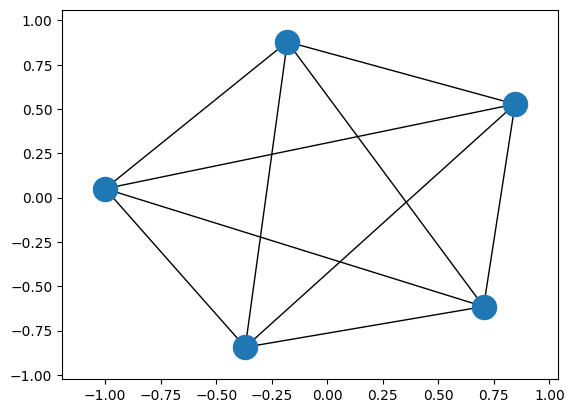

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
nx.draw(G, ax=ax)  # notice we call draw, and not draw_networkx_nodes
limits = plt.axis("on")  # turns on axis
ax.tick_params(left=True, bottom=True, labelleft=True, labelbottom=True)
# OBRAIN THESE COORDINATES AND PLOT THIS ONES